In [1]:

'''
Read data the following data:
    - pkt_count: logs the # of packets in each word bin by channel
    - too_few: logs the # of word bins with < 2 packets by channel

from a file previously created by the code "linearity_get_data". This data was 
obtained by putting a sweep of voltages (1.8V to 0) into the ADC bypassing the CSA. 
These voltages should result in a good dataword range from 200 to 800 or so. 

Graph various quantities which will:
    - flag any channels that are grossly non-linear
    - indicate the adequacy of the run setup for the purpose of this test
'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import tqdm

from tqdm import tqdm
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime

##########################################################
# Initialize parameters  
##########################################################

ramp = "9.77_2.37"
temp = "warm"
tile = 2
chip_serial_number = '4k03591'
runtime = 39

# set the range of datawords to test
max_dataword = 800
min_dataword = 260

# initialize
ig = 1 

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
def find_best_and_worst():
    
    global pkt_count, too_few, best_chip, worst_chip

    lowest_few  = 1E7
    most_few = 0
    best_chip = 0
    worst_chip = 0
    
    # find best and worst word-bin populated chips
    for chip in range(11,171):

        too_few_chip = 0
        
        for chan in range(0,64):
            too_few_chip = too_few_chip + too_few[chip][chan]

        if too_few_chip < lowest_few:
            best_chip = chip
            lowest_few = too_few_chip
            
        if too_few_chip > most_few:
            worst_chip = chip
            most_few = too_few_chip

    if best_chip > 0:
        print(f"\nBest  Chip {best_chip } had {lowest_few} word bins w < 2 pkts")
    else:
        print(f"\nNo best chip could be found")

    if worst_chip > 0:    
        print(f"\nWorst Chip {worst_chip} had {most_few } word bins w < 2 pkts, among its channels:")    
    else:
        print(f"\nNo worst chip could be found")
        
    lowest_few  = 1000
    most_few = -1
    best_chan = 100
    worst_chn = 100
    
    # find best and worst channels on worst chip    
    for chan in range(0,64):
        
        if too_few[worst_chip][chan] < lowest_few:
            best_chan = chan
            lowest_few = too_few[worst_chip][chan]

        if too_few[worst_chip][chan] > most_few:
            worst_chan = chan
            most_few = too_few[worst_chip][chan]

    if best_chan < 100:
        print(f"\tBest  Channel {best_chan } had {lowest_few} bins w < 2 pkts")
    else:
        print(f"\nNo best channel could be found")

    if worst_chan < 100:    
        print(f"\tWorst Channel {worst_chan} had {most_few } bins w < 2 pkts")    
    else:
        print(f"\nNo worst channel could be found")   
    
    return best_chip, worst_chip, best_chan, worst_chan


In [4]:
def graph_tile(tile):

    global pkt_count, too_few, ramp, chip_serial_number, temp

    too_few_list, chip_list = [], []
    
    for chip in range(11,171):
        count_list = np.array(too_few[chip]).flatten()
        too_few_list.append(np.sum(count_list))
        chip_list.append(chip)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(chip_list, too_few_list)
    ax.set_title(f'# Word Bins w < 2 pkts by Chip on Tile {tile}\n {ramp}s Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip')
    ax.set_ylabel(f'# Word Bins w < 2 pkts')
    plt.show 
    
    flatten_by_chip = np.array(too_few).flatten()
    too_few_list = flatten_by_chip.flatten()

    n_chans = len(too_few_list)
    n_5_chans = sum(1 for x in too_few_list if x < 5)
    n_0_chans = sum(1 for x in too_few_list if x == 0)
    
    print(f"\n{100 * n_5_chans / n_chans:.0f}% of channels on Tile {tile} have  < 5 sparse word bins")
    print(f"{100 * n_0_chans / n_chans:.0f}% of channels on Tile {tile} have zero sparse word bins")    
    
    mx = max(too_few_list)
    mn = min(too_few_list)
    print(f"The smallest # of word-bins with too few packets in 1 channel = {mn}")
    print(f"The largest  # of word-bins with too few packets in 1 channel = {mx}")
    n_bins = int(mx - mn +1)  
          
    fig, ax = plt.subplots(1,2, figsize=(14, 3))
    ax[0].hist(too_few_list, bins=n_bins)
    ax[0].set_title(f'# Word Bins w < 2 pkts per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'# Word Bins < 2 pkts')
    ax[0].set_ylabel(f'Channel Count')
    ax[0].set_yscale("log")

    ax[1].hist(too_few_list, bins=n_bins)
    ax[1].set_title(f'# Word Bins w < 2 pkts per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'# Word Bins < 2 pkts')
    ax[1].set_xlim(0,20)
    ax[1].set_yscale("log")
    
    plt.show 


In [5]:
def graph_chip(tile, chip, quality):
    
    global pkt_count, too_few, chip_serial_number
    
    too_few_list, chan_list = [],[]
    
    for chan in range(0,64):
    
        too_few_list.append(too_few[chip][chan])
        chan_list.append(chan)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(chan_list, too_few_list)
    ax.set_title(f'Word-bins w < 2 pkts by Channel on {quality} Chip {chip}\nTest of v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Channel')
    ax.set_ylabel(f'# Word-bins w < 2 pkts')
    plt.show                 

    return

In [6]:
def graph_channel(tile, chip, chan, quality):

    global pkt_count, chip_serial_number, max_dataword, min_dataword
    
    count_list, word_list = [],[]

    looking = True
    
    # find the first word bin that has data using "looking"
    for word in range(min_dataword, max_dataword):

        if pkt_count[chip][chan][word] > 0 and looking:
            looking = False

        if not looking:
            count_list.append(pkt_count[chip][chan][word])
            word_list.append(word)
    
    n_low = sum(1 for x in count_list if x<2)

    mean_count = np.mean(count_list)
    std_count  = np.std(count_list)
    min_count  = min(count_list)
    max_count  = max(count_list)

    nbins = max_count - min_count +1
    
    fig, ax = plt.subplots(1,2, figsize=(14, 3))

    ax[0].plot(word_list, count_list, marker = 'o', linestyle = '')
    ax[0].set_title(f'# Pkts in Word bins for {quality} Channel {chan} on Worst Chip {chip}\n{n_low} bins have < 2pkts, Test of v3a Tile #{tile} ({chip_serial_number})')
    ax[0].axhline(y = mean_count, color='r', linestyle='-', linewidth=2) 
    ax[0].axhline(y = mean_count+std_count, color='r', linestyle='--', linewidth=2) 
    ax[0].axhline(y = mean_count-std_count, color='r', linestyle='--', linewidth=2)         
    ax[0].set_xlabel(f'ADC Dataword')
    ax[0].set_ylabel(f'# Packets')
    
    ax[1].hist(count_list, bins = nbins)
    ax[1].set_title(f'# Pkts in Word bins for {quality} Channel {chan} on Worst Chip {chip}\n{n_low} bins have < 2pkts, Test of v3a Tile #{tile} ({chip_serial_number})')
    ax[1].axvline(x = mean_count, color='r', linestyle='-', linewidth=2) 
    ax[1].axvline(x = mean_count+std_count, color='r', linestyle='--', linewidth=2) 
    ax[1].axvline(x = mean_count-std_count, color='r', linestyle='--', linewidth=2)         
    ax[1].set_xlabel(f'# Packets')
    ax[1].set_ylabel(f'Dataword Count')

    plt.show
    
    return    

In [7]:
def get_std_pkt_count(tile):
    
    global pkt_count, ramp, chip_serial_number, min_dataword, max_dataword

    std_list = []
    
    for chip in range(62,63):
        for chan in range(0,64):
            word_counts = []
            for word in range(min_dataword, max_dataword):
                word_counts.append(pkt_count[chip][chan][word])
            #word_counts = np.array(pkt_count[chip][chan]).flatten()
            std_chan = np.std(word_counts)
            std_list.append(std_chan)

    mx = max(std_list)
    mn = min(std_list)
    
    fig, ax = plt.subplots(1,2, figsize=(14, 3))

    ax[0].hist(std_list, bins = 100)
    ax[0].set_title(f'Stdev(Word Bin Count) per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'Stdev(Word Bin Count)')
    ax[0].set_ylabel(f'Channel Count')
    ax[0].set_yscale("log")

    ax[1].hist(std_list, bins = 100)
    ax[1].set_title(f'Stdev(Word Bin Count) per Channel on Tile {tile}\n {ramp} ramp Voltage Sweep, v3a Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'Stdev(Word Bin Count)')
    ax[1].set_yscale("log")
    ax[1].set_xlim(0,25)
    
    plt.show 

In [8]:
def read_data():

    global total_livetime, file, ramp, temp, chip_serial_number, pkt_count, too_few, runtime
    
#    filename = '../data/linearity_data_{temp}_tile{tile}_{chip_serial_number}_{ramp}ramp_{runtime}m.hdf5'
    filename =  '../data/linearity_data_warm_tile2_4k603591_9.77_2.37ramp_39m.hdf5'   

    with h5py.File(filename, 'r') as f:
            
        too_few   = f['too_few'][:]
        pkt_count = f['pkt_count'][:]        
        
        f.close()  

    print(f"\n\nData read from {filename}\n\n")
    
    return    



Data read from ../data/linearity_data_warm_tile2_4k603591_9.77_2.37ramp_39m.hdf5



87% of channels on Tile 2 have  < 5 sparse word bins
39% of channels on Tile 2 have zero sparse word bins
The smallest # of word-bins with too few packets in 1 channel = 0
The largest  # of word-bins with too few packets in 1 channel = 270

Best  Chip 78 had 155 word bins w < 2 pkts

Worst Chip 62 had 434 word bins w < 2 pkts, among its channels:
	Best  Channel 9 had 0 bins w < 2 pkts
	Worst Channel 40 had 270 bins w < 2 pkts


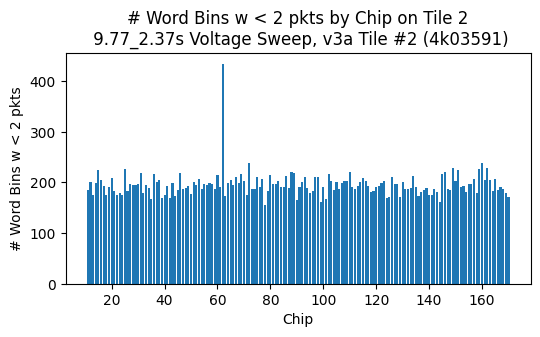

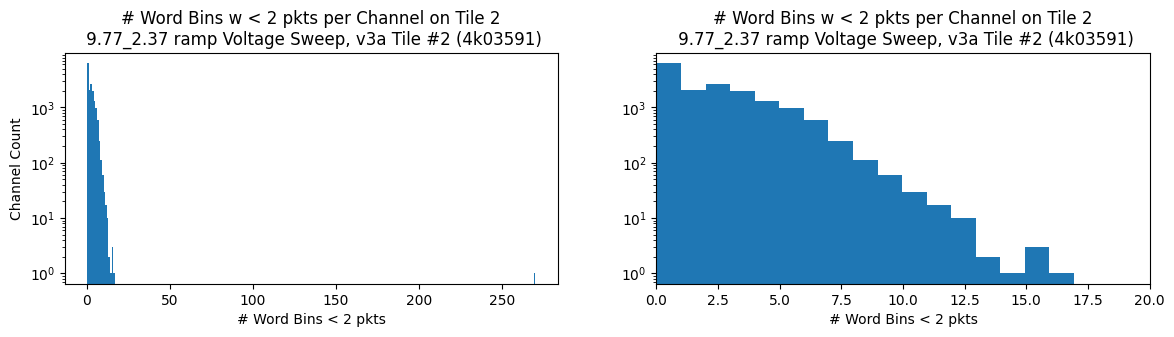

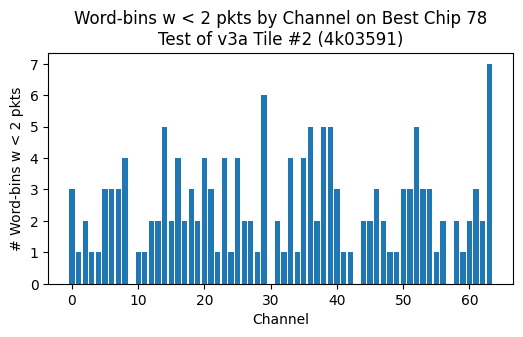

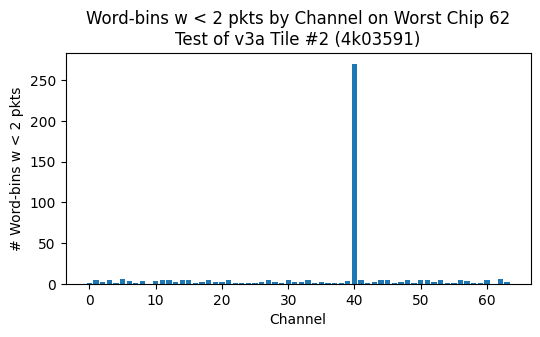

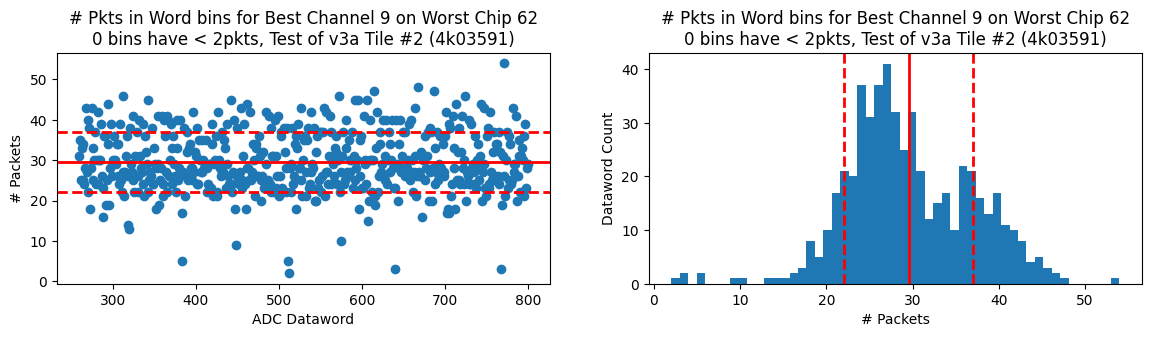

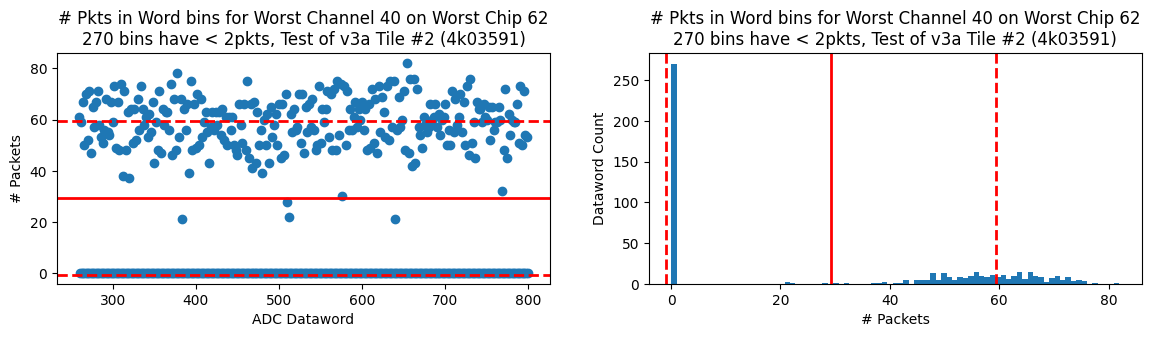

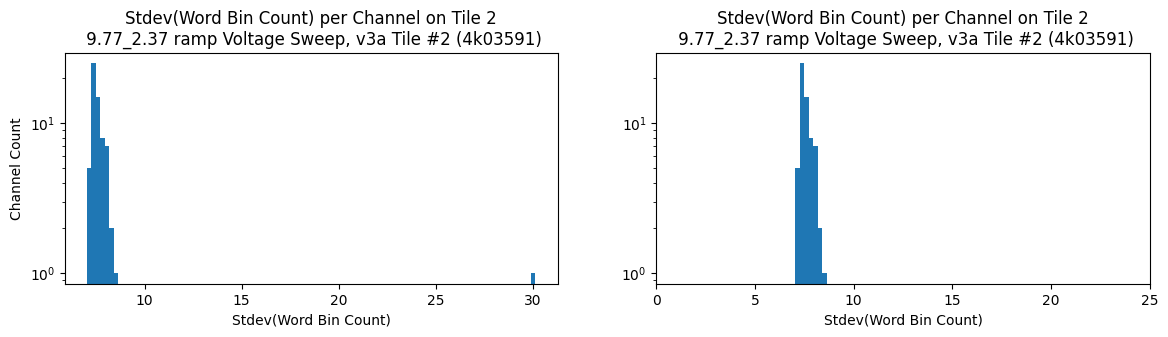

In [9]:
####################
# main
####################

# read pkt_count and too_few arrays data from the file created by previously running "linearity_get_data"
read_data()

# graph the distribution of sparse word counts by chip for the tile
graph_tile(tile)

# find the best and worst chips in terms of sparse word counts
# for the worst chip find the best and worst channels
best_chip, worst_chip, best_chan, worst_chan = find_best_and_worst()

# graph the best and worst cases
graph_chip(tile, best_chip, "Best")
graph_chip(tile, worst_chip, "Worst")
graph_channel(tile, worst_chip, best_chan , "Best")
graph_channel(tile, worst_chip, worst_chan, "Worst")

# get the standard deviation of packet counts per channel
get_std_pkt_count(tile)